In [1]:
#system
import os
import sys
sys.path.insert(0, "/home/thomasb/")

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
import rfitools
import numba as nb
from pyuvdata import UVData
import importlib
importlib.reload(rfitools)
import time

from albatros_analysis.scripts.mapmaking import map_utils as mutils
from albatros_analysis.src.correlations import timing_solution_class as tsc

importlib.reload(mutils)

<module 'albatros_analysis.scripts.mapmaking.map_utils' from '/home/thomasb/albatros_analysis/scripts/mapmaking/map_utils.py'>

In [2]:
#simulated data
filename = "/scratch/achokshi/pyuvsim/uvh5/albatros_sim_ateam_20MHz_256chans_1SD_0.5s_uni.uvh5"
uvd = UVData.from_file(filename, read_data = True, frequencies=[19872000,])

In [2]:
#actual data
with np.load('/home/mohanagr/Jupyter/MARS Fringe analysis (Summer 2025)/vis_dump.npz') as f:
    vis=f['vis']
    cnt=f['cnt']
    tstart=f['tstart']
    deltat=f['deltat']
    deltaf=f['deltaf']

In [3]:
fstart = 360*250e6/4096
print('vis shape', vis.shape)
print('vis size (KB)', vis.nbytes/1024)

print('starting time', tstart)
print('integration time', deltat)

print('starting frequency', fstart)
print('channel width', deltaf)

vis shape (10, 410, 21)
vis size (KB) 672.65625
starting time 1753264833.6433537
integration time 1.073741824
starting frequency 21972656.25
channel width 4768.37158203125


In [4]:
vis.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [5]:
nant=7
triu_idx=np.triu_indices(nant,k=1)
nbl = len(triu_idx[0])
print('nblines', nbl)

nblines 21


This is either to check data presense or RFI, I can't figure it out

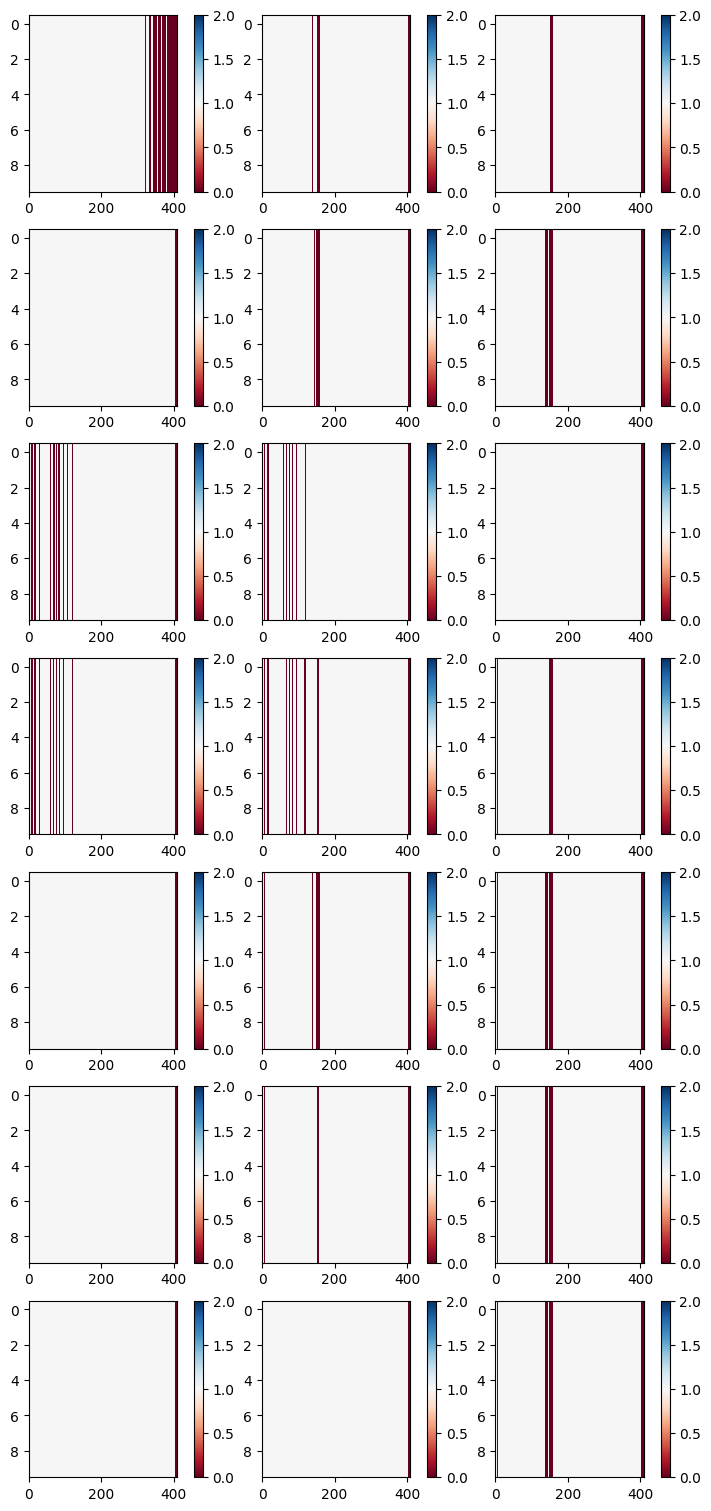

In [6]:
fig,ax = plt.subplots(7,3, layout='constrained')
fig.set_size_inches(7,15)
ax=np.ravel(ax)
pnum=0
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    # ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} bl_id={(i)}")
    # img=ax[pnum].imshow(np.angle(vis[:,:,i]),aspect='auto',cmap='RdBu',interpolation='none')
    img=ax[pnum].imshow(cnt[:,:,i]>0,aspect='auto',cmap='RdBu',interpolation='none',vmin=0, vmax=2)
    cbar=plt.colorbar(img,ax=ax[pnum])
    # ax[pnum].set_ylim(600,800)
    # ax[pnum].set_ylim(2000,4000)
    pnum+=1

In [7]:
#average in time to get visibilities with about 10 seconds accumulation time
vis_avg = np.mean(vis,axis=0)
cnt_avg = np.sum(cnt,axis=0)

print('vis averaged shape:', vis_avg.shape)

vis averaged shape: (410, 21)


In [8]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938],  #CSA
        3: [79.418302573, -90.667395452, 59.6242],  #MARS5
        4: [79.397984238, -90.799842408, 41.6994],  #MARS6
        5: [79.411474117, -90.695266129, 31.6314],  #MARS7
        6: [79.443757694, -90.718202634, 414.9131]  #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}

NSIDE = 1024

# GET MAP

We start by working through a single time entry for both corrected and uncorrected delays (clock drift and such)

In [9]:
# determine the number of pixels
NPIX=hp.nside2npix(NSIDE)
print(NPIX)

# determine the pixel resolution
pix_res = hp.nside2resol(NSIDE,arcmin=True)
print(pix_res)

# get sky coordinates of each pixel in dec, ra
co_dec, ra = hp.pix2ang(NSIDE,np.arange(NPIX))
dec = np.pi/2-co_dec

12582912
3.435486411817406


In [ ]:
# set up ant0 as a location
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [11]:
# figure out what the observation time is (for visibility index t_idx)
t_idx = 0
obstime0 = Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
print(obstime0)
obstime0_unix = obstime0.unix
print(obstime0.unix)

# get the sky coordinates of each pixel into alt/az
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
pix_altaz =src.transform_to(AltAz(location=ant0,obstime=obstime0))

1753264834.1802247
1753264834.1802247


In [12]:
#baseline ENU distances for all blines
bl_enus_all = mutils.get_all_bls(coords, np.arange(len(coords)), enu=True)

#baseline ENU distances only for blines that are in reference 
bl_enus_ref =  mutils.get_all_bls(coords,np.arange(len(coords)), enu=True, refonly=True)

(21, 3)
(7, 3)


In [13]:
#delays for each baseline, for each pixel
delays_all = mutils.geo_delay_from_enu(bl_enus_all, pix_altaz.az.value, pix_altaz.alt.value)

#delays for each baseline with reference antenna in it
delays_ref = mutils.geo_delay_from_enu(bl_enus_ref, pix_altaz.az.value, pix_altaz.alt.value)

#get the delays for the simulated data
#sim_delays = geo_delay(uvd.get_enu_data_ants()[0], altaz.alt.value, altaz.az.value)

print('delays_all shape', delays_all.shape)
print('delays_ref shape', delays_ref.shape)
#print('sim delays shape', sim_delays.shape)

delays_all shape (21, 12582912)
delays_ref shape (7, 12582912)


In [14]:
#get clock delays
obj = tsc.TimingSolution('/scratch/thomasb/timing_solution')
obstimes_unix, delays_clock = obj.find_timing_sol(obstime0_unix, obstime0_unix+10*deltat, deltat)
print(obstimes_unix.shape)
print(delays_clock.shape)
#get baselines associated with the clock delays
ref_ant = obj.find_ref_ant(obstime0_unix, obstime0_unix + 10)
other_ants = obj.find_other_ants(obstime0_unix, obstime0_unix + 10)

Your data lives in batch_1753200150
number of baselines in tau data: 6
number of queried unix times: 10
number of data unix times (1560,)
(10,)
(6, 10)


In [15]:
print(other_ants)

['MARS2', 'MARS4', 'MARS5', 'MARS6', 'MARS7', 'MARS8']


In [16]:
#make full array all blines
delays_clock_all = np.zeros((nbl, len(obstimes_unix)))
#add zero delays at start for MARS1
d = np.vstack([np.zeros((1, len(obstimes_unix))),delays_clock])

blid = 0
for i in range(0, len(d)):
    tausi = d[i, :]
    for j in range(i+1, len(d)):
        tausj = d[j,:]
        delays_clock_all[blid, :]  = tausj - tausi #careful with convention!!
        blid+=1

blid = 0
#sanity check
#print(delays_clock[blid,:])
#print(delays_clock_all[blid,:])
print('all clock delays shape', delays_clock_all.shape)

all clock delays shape (21, 10)


In [17]:
delays_all_corr = delays_all + delays_clock_all[:, 0, None]*1e-9

In [18]:
#check that delays_all and delays_ref agree (they seem to agree)
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(np.max(np.abs(delays_all[i] - (delays_ref[aj]-delays_ref[ai]))))

0.0
0.0
0.0
0.0
0.0
0.0
1.3552527156068805e-20
3.3881317890172014e-21
5.082197683525802e-21
3.3881317890172014e-21
6.776263578034403e-21
1.3552527156068805e-20
1.1858461261560205e-20
1.3552527156068805e-20
1.6940658945086007e-20
5.082197683525802e-21
3.8116482626443515e-21
6.776263578034403e-21
5.082197683525802e-21
1.0164395367051604e-20
6.776263578034403e-21


In [19]:
#chek baseline lengths
bl_lengths = np.sqrt(np.sum(bl_enus_all*bl_enus_all,axis=1))
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(antmap[ai], antmap[aj], '|', i,ai,aj, '|', bl_lengths[i])

MARS1 MARS2 | 0 0 1 | 174.45456775051662
MARS1 MARS4 | 1 0 2 | 6089.384461074008
MARS1 MARS5 | 2 0 3 | 2055.7884567985097
MARS1 MARS6 | 3 0 4 | 2248.2290395629816
MARS1 MARS7 | 4 0 5 | 1614.993536696582
MARS1 MARS8 | 5 0 6 | 3143.2792581319386
MARS2 MARS4 | 6 1 2 | 6240.3838025376035
MARS2 MARS5 | 7 1 3 | 1881.5962163339905
MARS2 MARS6 | 8 1 4 | 2309.689734452764
MARS2 MARS7 | 9 1 5 | 1458.5268016563846
MARS2 MARS8 | 10 1 6 | 3088.474324240012
MARS4 MARS5 | 11 2 3 | 7956.833009844907
MARS4 MARS6 | 12 2 4 | 4633.21326925574
MARS4 MARS7 | 13 2 5 | 7133.9978322114575
MARS4 MARS8 | 14 2 6 | 8741.141688683856
MARS5 MARS6 | 15 3 4 | 3541.1607982782593
MARS5 MARS7 | 16 3 5 | 953.4344496617705
MARS5 MARS8 | 17 3 6 | 3047.6686048967063
MARS6 MARS7 | 18 4 5 | 2623.064250068337
MARS6 MARS8 | 19 4 6 | 5391.147752404277
MARS7 MARS8 | 20 5 6 | 3655.4414760084646


In [20]:
#make the fringes from delays_all, at the starting frequency
fringes_all = np.exp(2j*np.pi * 21e6 * delays_all)
print(fringes_all.shape)

(21, 12582912)


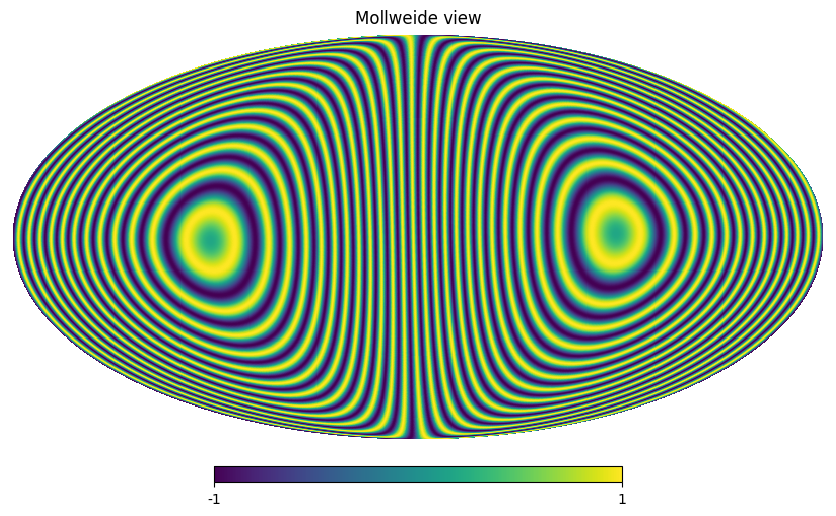

In [21]:
#plot fringes for different baseline indices
blidx = 0
hp.mollview(fringes_all[blidx,:].real)

In [22]:
#get frequencies for all channels
freqs_all = np.arange(vis.shape[1]) * deltaf + fstart #Hz

In [23]:
#get the good frequencies
good_freq_idx = np.bitwise_and.reduce(cnt[0,:,1:]>0, axis=1)
good_freqs = freqs_all[good_freq_idx].copy()
print("good freqs",len(good_freqs))

good freqs 334


In [24]:
#get delays as a matrix, excluding MARS1-MARS2
delaysT = delays_all[1:,:].T.copy()
delaysT_corr = delays_all_corr[1:,:].T.copy()

#get data
data = vis[0, good_freq_idx, 1:].copy()

In [25]:
map = mutils.get_map(data, good_freqs, delaysT, NPIX)

(334, 20) (334,) (12582912, 20)


In [33]:
map_corr = mutils.get_map(data, good_freqs, delaysT_corr, NPIX)

(334, 20) (334,) (12582912, 20)


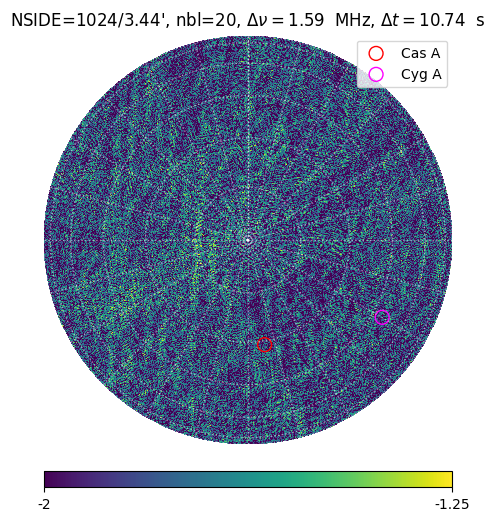

In [32]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={nbl-1}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

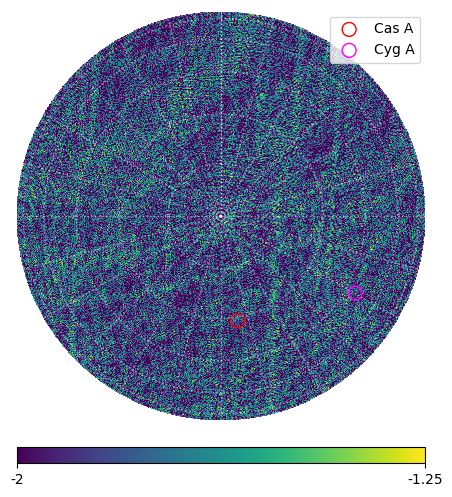

In [34]:
plot_map(map_corr)

In [ ]:
# big loop da loop
maps = np.zeros((vis.shape[0],NPIX), dtype='complex128')
for t_idx in range(vis.shape[0]):
    #figure out the observation time in center of visibility
    obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
    print(obstime)

    #figure out what each pixel's sky coordinates are in alt/az
    src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
    pix_altaz = src.transform_to(AltAz(location=ant0,obstime=obstime))

    #get corresponding delays for each baseline
    delays_all = geo_delay(bl_enus_all, pix_altaz.alt.value, pix_altaz.az.value)
    
    #get the good frequencies
    good_freq_idx = np.bitwise_and.reduce(cnt[t_idx,:,1:]>0, axis=1)
    good_freqs = freqs_all[good_freq_idx].copy()
    print("good freqs",len(good_freqs))

    #get delays as a matrix, excluding MARS1-MARS2
    delaysT = delays_all[1:,:].T.copy()
    data = vis[t_idx, good_freq_idx, 1:].copy()

    #compute the map
    t1=time.time()
    maps[t_idx, :] = mutils.get_map(data,good_freqs,delaysT,NPIX)
    t2=time.time()
    print(t2-t1)

1753264834.1802247
good freqs 334
(334, 20) (334,) (12582912, 20)
1083.3013060092926
1753264835.2539666
good freqs 334
(334, 20) (334,) (12582912, 20)
936.8270380496979
1753264836.3277082
good freqs 334
(334, 20) (334,) (12582912, 20)


In [ ]:
avg_map = np.mean(maps, axis=0)

In [ ]:
map1 = maps[0, :]

In [29]:
def plot_map(map, half_sky=True, title=None, sources=True, view='orth', vmin=-2, vmax=-1.25, scale = 'dB'):

    assert view in ['orth', 'moll']
    assert scale in ['dB', 'abs', 'real']

    #turn into the scaling type you want
    if scale =='dB':
        #to avoid log of zero
        map = np.log10(np.maximum(np.abs(map), 1e-30))
    elif scale == 'abs':
        map = np.abs(map)
    elif scale =='real':
        map = np.real(map)

    #plot it
    if view == 'orth':
        hp.orthview(map, min=vmin, max=vmax, rot=(0,90), half_sky=half_sky, title=title)
    if view == 'moll':
        hp.mollview(map, min=vmin, max=vmax, rot=(0,90), half_sky=half_sky, title=title)
    hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')

    #optionally plot bright sources and their location
    if sources:
        
        cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
        cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs')

        hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
            marker='o',       # Circle marker
            facecolors='none',# Hollow circle
            edgecolors='red', # Red outline
            s=100,            # Size of the circle
            lw=1,             # Line width
            label='Cas A')

        hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
            marker='o',       # Circle marker
            facecolors='none',# Hollow circle
            edgecolors='magenta', # Red outline
            s=100,            # Size of the circle
            lw=1,             # Line width
            label='Cyg A')

        plt.legend()

    plt.show()

In [ ]:
#determine bandwidth
bw=len(good_freqs)*deltaf

title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"

#log of map magnitude for each pixel
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)

#
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')

#bright sources and their location
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

In [12]:
uvd.time_array

array([2460676.5       , 2460676.5       , 2460676.5       , ...,
       2460677.49726273, 2460677.49726273, 2460677.49726273])

In [13]:
sim_ncross = len(np.unique(uvd.baseline_array))
print(len(uvd.time_array[::sim_ncross]))

sim_obstime = Time(uvd.time_array[::sim_ncross],format="jd",scale="utc")
sim_lst = sim_obstime.sidereal_time('apparent', longitude=ant0.lon)

print(sim_lst)

172328
[0h40m31.81389251s 0h40m32.31527897s 0h40m32.81662508s ...
 0h40m30.22683801s 0h40m30.72818411s 0h40m31.22957055s]


resol 3.435486411817406 npix 12582912
1753264834.1802247


In [15]:
real_lst = obstime.sidereal_time('apparent',longitude=ant0.lon)
real_lst

<Longitude 0.05156559 hourangle>

In [16]:
lst_idx = np.argmin(np.abs(real_lst-sim_lst))

In [17]:
uvd.data_array.shape

(6203808, 1, 4)

In [18]:
uvd.time_array[::sim_ncross][lst_idx]

2460677.4713425925

In [19]:
Time(2460677.4713425925,format="jd",scale="utc").sidereal_time('apparent', longitude=ant0.lon)

<Longitude 0.05155497 hourangle>

In [20]:
uvd.select(antenna_nums=[0,1,3,4,5,6,7],times=[2460677.4713425925,],polarizations=['ee','nn'])

In [21]:
uvd.data_array.flags

  C_CONTIGUOUS : True
  F_CONTIGUOUS : False
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [22]:
sim_data = uvd.data_array.copy()

In [23]:
#get simulated average visibilities
sim_data = np.mean(sim_data,axis=2)

sim_vis = np.zeros((1,nbl),dtype='complex128')
idx=0
for i, pair in enumerate(uvd.get_antpairs()):
    if pair[0]==pair[1]:
        continue
    else:
        sim_vis[0,idx]=sim_data[i,0]
    idx+=1

In [24]:
sim_data

array([[ 55263.18341966    +0.j        ],
       [ 28380.97407401+13617.61489418j],
       [-34087.70878719-12468.92567789j],
       [-26144.1245055 +43354.630347j  ],
       [-15667.37820936+31675.43846717j],
       [-20403.69240141+41860.18069208j],
       [ 34951.81398964-14297.75693139j],
       [ 55263.18341966    +0.j        ],
       [-20235.97645344 -4307.1200017j ],
       [ -5820.28279922+36169.35738647j],
       [ -4303.93538004+46703.3811144j ],
       [  3311.83424525+24628.10624418j],
       [ 31284.57163912-27575.5428306j ],
       [ 55263.18341966    +0.j        ],
       [  2550.78451138-29232.62273748j],
       [ -6551.34716452-30181.77785284j],
       [  2082.68492986-31787.01396924j],
       [-14007.27707423+20985.67745902j],
       [ 55263.18341966    +0.j        ],
       [ 38715.03367945 -8615.81168552j],
       [ 43904.19600333 -3531.7267261j ],
       [-33411.78361002-25810.17162282j],
       [ 55263.18341966    +0.j        ],
       [ 29875.89850062  -366.4591

In [25]:
sim_vis

array([[ 28380.97407401+13617.61489418j, -34087.70878719-12468.92567789j,
        -26144.1245055 +43354.630347j  , -15667.37820936+31675.43846717j,
        -20403.69240141+41860.18069208j,  34951.81398964-14297.75693139j,
        -20235.97645344 -4307.1200017j ,  -5820.28279922+36169.35738647j,
         -4303.93538004+46703.3811144j ,   3311.83424525+24628.10624418j,
         31284.57163912-27575.5428306j ,   2550.78451138-29232.62273748j,
         -6551.34716452-30181.77785284j,   2082.68492986-31787.01396924j,
        -14007.27707423+20985.67745902j,  38715.03367945 -8615.81168552j,
         43904.19600333 -3531.7267261j , -33411.78361002-25810.17162282j,
         29875.89850062  -366.45919654j, -23162.32486162-30364.38570296j,
        -26629.90757991-29231.37787683j]])

In [26]:
altaz

<SkyCoord (AltAz: obstime=1753264834.1802247, location=(-15736.85693402, -1175125.30163555, 6248101.17426522) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    [(1.82472677e-01,  79.3118883 ), (1.84078707e-01,  79.24728142),
     (3.59837806e+02,  79.24679174), ..., (1.79806190e+02, -79.3016997 ),
     (1.80154233e+02, -79.30222345), (1.80156005e+02, -79.23761416)]>

In [33]:
#check the delays for for one pixel, for all blines
dd = delays[:,0]
print(delays[:,0] - (dd[triu_idx[1]]-dd[triu_idx[0]])) # a numpy trick to generate per baseline delays

[ 2.50274513e-06 -2.20442774e-06  1.45561168e-06 -9.17268799e-07
 -3.49645632e-06  5.08360479e-06 -4.70717286e-06 -1.04713345e-06
 -3.42001393e-06 -5.99920145e-06  2.58085966e-06  3.66003942e-06
  1.28715894e-06 -1.29202859e-06  7.28803253e-06 -2.37288048e-06
 -4.95206800e-06  3.62799311e-06 -2.57918752e-06  6.00087359e-06
  8.58006111e-06]


In [34]:
#exclude MARS1-MARS2
good_bls = np.arange(1,nbl)
#check that there are more than 10 in all baselines
good_freq_idx = np.bitwise_and.reduce(cnt_avg[:,good_bls]>10, axis=1)  #across all baselines, excluding MARS1-2 because we wont use it
print(good_bls)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


number of good channels: 334


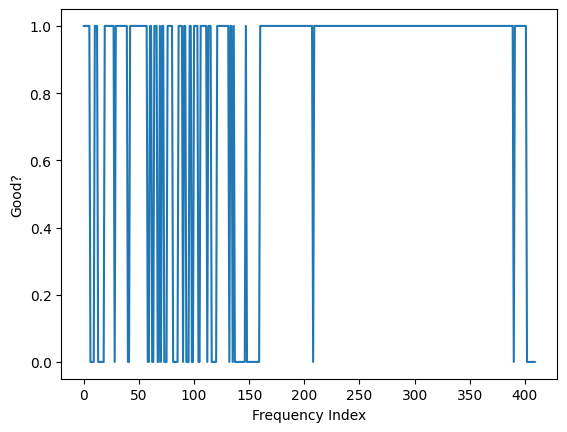

In [35]:
plt.plot(good_freq_idx)
plt.xlabel('Frequency Index')
plt.ylabel('Good?')
print('number of good channels:', np.sum(good_freq_idx))

In [ ]:
#get array of good frequencies (ones with enough data in them)
good_freqs = freqs[good_freq_idx].copy()
print('number of good frequencies:', len(good_freqs))

number of good frequencies: 334


In [37]:
delaysT = delays[good_bls,:].T.copy() #exclude MARS1-2
sim_delaysT = sim_delays.T.copy()

data = vis[t_idx, good_freq_idx, 1:].copy() #exclude MARS1-2
data_avg = vis_avg[:, good_bls][good_freq_idx, :].copy() #exclude MARS1-2

print('data shape', data.shape)
print('data avg shape', data_avg.shape)
print('delaysT shape', delaysT.shape)
print('simdelaysT shape', sim_delaysT.shape)

data shape (334, 20)
data avg shape (334, 20)
delaysT shape (12582912, 20)
simdelaysT shape (12582912, 7)


In [38]:
sim_map = get_map(sim_vis,np.asarray([19872000],dtype='float64'),sim_delaysT,NPIX)
print(sim_map.shape)

(1, 21) (1,) (12582912, 7)
pixel 0
pixel 8389000
pixel 6292000
pixel 4195000
pixel 1000
pixel 10486000
pixel 2098000
pixel 8390000
pixel 6293000
pixel 4196000
pixel 10487000
pixel 2099000
pixel 8391000
pixel 6294000
pixel 4197000
pixel 10488000
pixel 2100000
pixel 8392000
pixel 6295000
pixel 4198000
pixel 10489000
pixel 2101000
pixel 8393000
pixel 6296000
pixel 4199000
pixel 10490000
pixel 2102000
pixel 8394000
pixel 6297000
pixel 4200000
pixel 10491000
pixel 2103000
pixel 8395000
pixel 6298000
pixel 4201000
pixel 10492000
pixel 2104000
pixel 8396000
pixel 6299000
pixel 4202000
pixel 10493000
pixel 2105000
pixel 8397000
pixel 6300000
pixel 4203000
pixel 10494000
pixel 2106000
pixel 8398000
pixel 6301000
pixel 4204000
pixel 10495000
pixel 2107000
pixel 8399000
pixel 6302000
pixel 4205000
pixel 10496000
pixel 2108000
pixel 8400000
pixel 6303000
pixel 4206000
pixel 8401000
pixel 2109000
pixel 6304000
pixel 4207000
pixel 2000
pixel 8402000
pixel 2110000
pixel 6305000
pixel 4208000
pixel 30

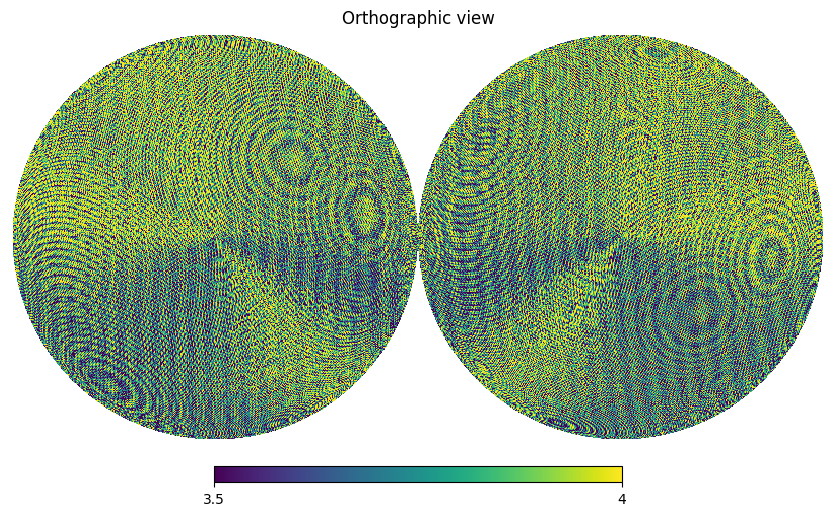

In [39]:
hp.orthview(np.log10(np.abs(sim_map)),rot=(0,90),min=3.5,max=4,
    #half_sky=True
)

In [41]:
delays1-sim_delays

array([[ 3.10767547e-18,  3.10771062e-18,  3.10565174e-18, ...,
        -3.10545335e-18, -3.10751264e-18, -3.10754719e-18],
       [ 2.35450217e-08,  2.35395888e-08,  2.35294144e-08, ...,
        -2.35332043e-08, -2.35433816e-08, -2.35379440e-08],
       [ 1.93130555e-08,  1.93157742e-08,  1.93019381e-08, ...,
        -1.92984927e-08, -1.93123314e-08, -1.93150465e-08],
       ...,
       [-2.35059264e-09, -2.34727922e-09, -2.35081420e-09, ...,
         2.35392274e-09,  2.35038787e-09,  2.34707387e-09],
       [-2.24241287e-09, -2.23907501e-09, -2.24210274e-09, ...,
         2.24519054e-09,  2.24216292e-09,  2.23882451e-09],
       [-5.58323616e-09, -5.58048910e-09, -5.58516125e-09, ...,
         5.58788111e-09,  5.58320935e-09,  5.58046113e-09]])

In [47]:
_ = get_map(data,good_freqs,delaysT,100)

(334, 20) (334,) (12582912, 20)


In [ ]:
t1=time.time()
map1 = get_map(data,good_freqs,delaysT,NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (12582912, 20)


In [81]:
t1=time.time()
map2 = get_map(data,good_freqs,delaysT,NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (12582912, 20)


984.717084646225


In [48]:
# big loop da loop
maps = np.zeros((vis.shape[0],NPIX), dtype='complex128')
for t_idx in range(vis.shape[0]):
    obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
    print(obstime)
    src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
    altaz =src.transform_to(AltAz(location=ant0,obstime=obstime))
    delays = geo_delay(bl_enus, altaz.alt.value, altaz.az.value)
    good_freq_idx = np.bitwise_and.reduce(cnt[t_idx,:,1:]>0, axis=1)
    good_freqs = freqs[good_freq_idx].copy()
    print("good freqs",len(good_freqs))
    delaysT = delays[1:,:].T.copy() #exclude MARS1-2
    data = vis[t_idx, good_freq_idx, 1:].copy() #exclude MARS1-2
    t1=time.time()
    maps[t_idx, :] = get_map(data,good_freqs,delaysT,NPIX)
    t2=time.time()
    print(t2-t1)

1753264834.1802247
good freqs 334
(334, 20) (334,) (12582912, 20)
954.0922229290009
1753264835.2539666
good freqs 334
(334, 20) (334,) (12582912, 20)


KeyboardInterrupt: 

In [224]:
avg_map = np.mean(maps, axis=0)

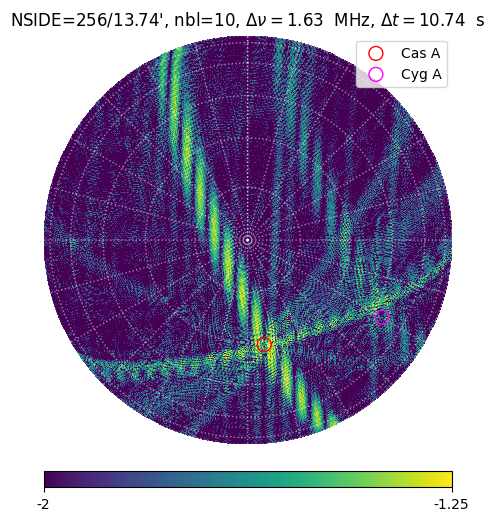

In [171]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

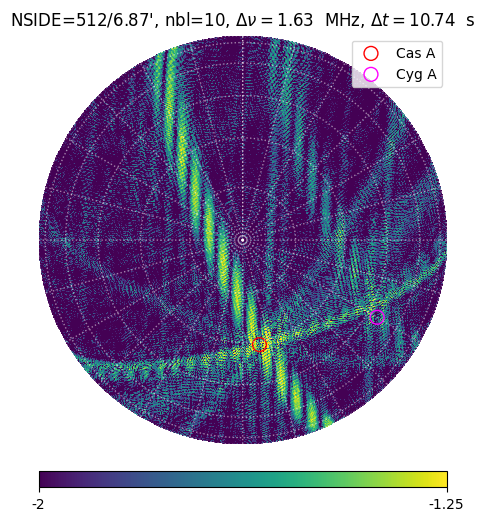

In [185]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

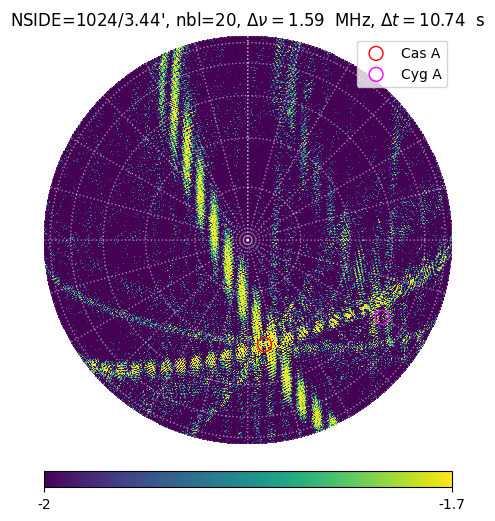

In [235]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(0,90),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

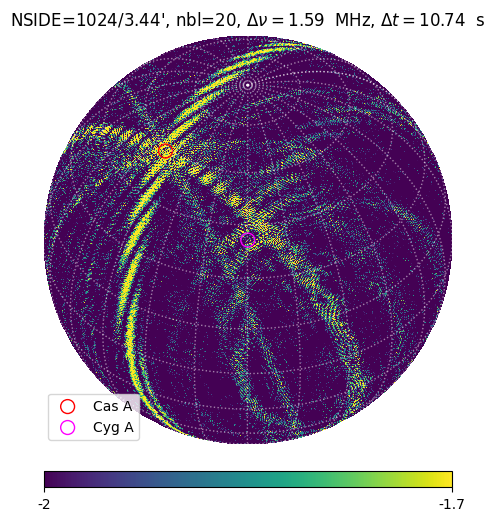

In [236]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(cyg_a.ra.deg,cyg_a.dec.deg),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')


hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

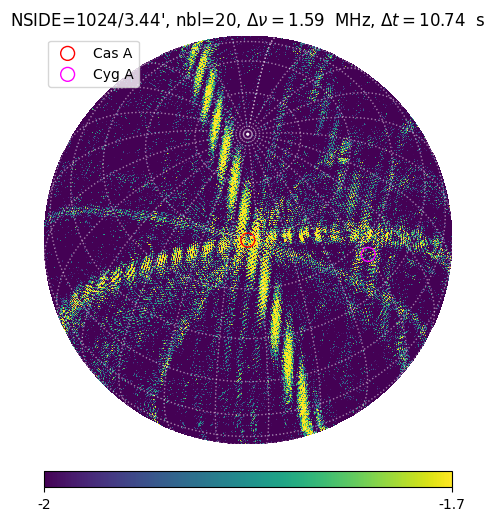

In [237]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(cas_a.ra.deg,cas_a.dec.deg),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')


hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

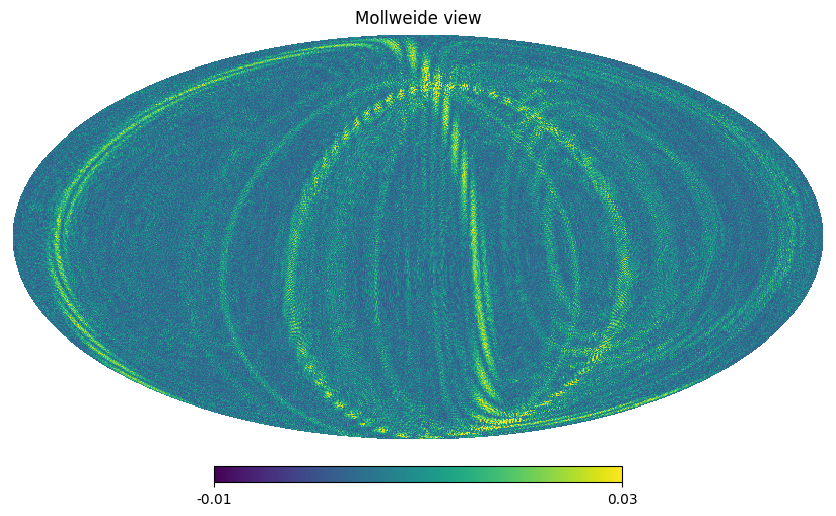

In [112]:
hp.mollview(np.abs(map1),min=-0.01,max=0.03)

## low res map with short bls

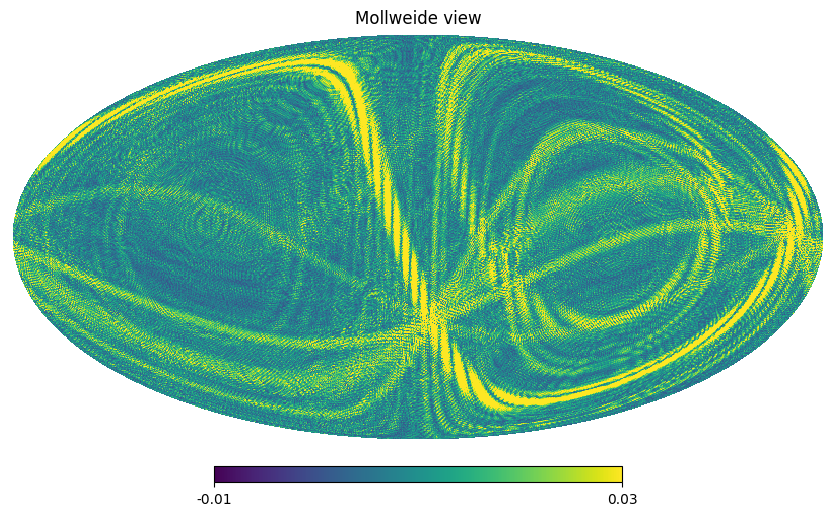

In [74]:
hp.mollview(np.abs(map1),min=-0.01,max=0.03, rot=(0,90))

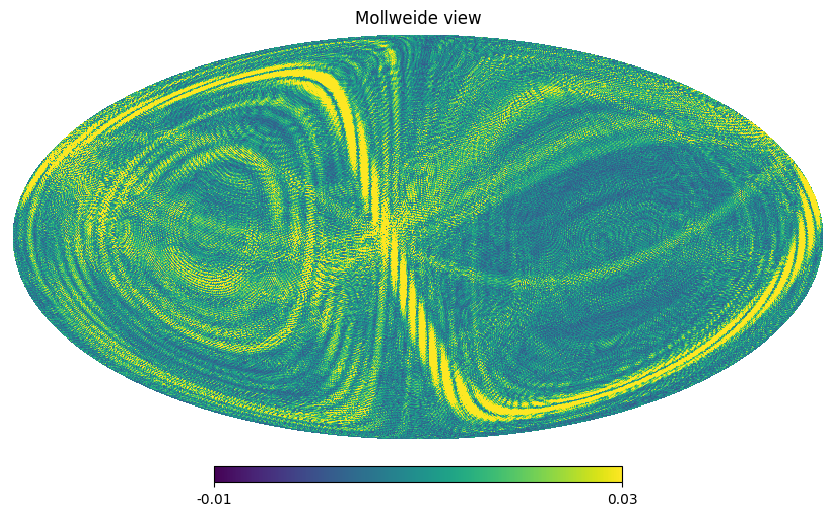

In [73]:
hp.mollview(np.abs(map2),min=-0.01,max=0.03, rot=(0,90))

## Baslines only with MARS8

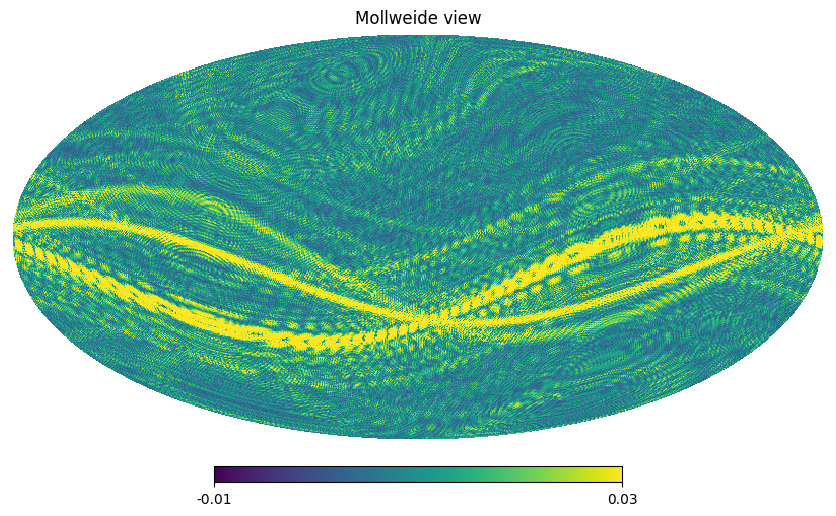

In [92]:
hp.mollview(np.abs(map1),min=-0.01,max=0.03, rot=(0,90))

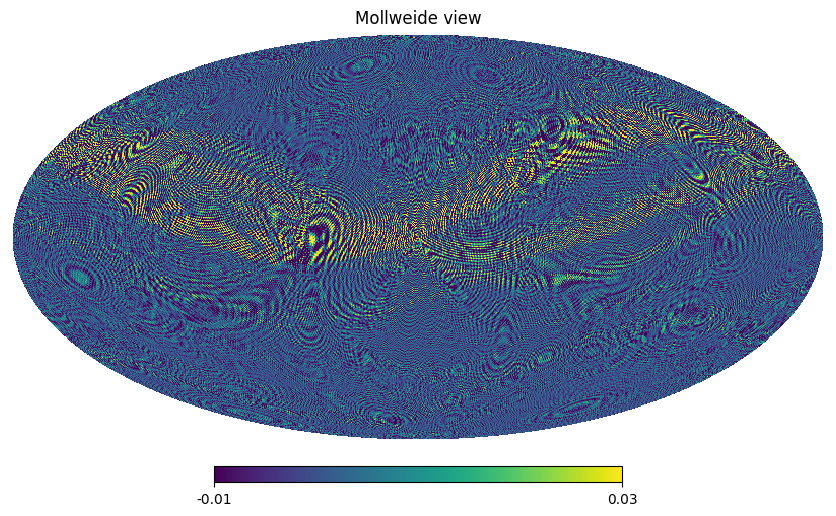

In [94]:
hp.mollview(np.real(map2),min=-0.01,max=0.03, rot=(0,90))